<a href="https://colab.research.google.com/github/bencejdanko/multimodal-retrieval-flickr-30k-clip-blip/blob/main/blip_flickr30k_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BLIP Training

In [ ]:
!pip install -q transformers peft "datasets<3.0.0" evaluate rouge_score bert_score nltk huggingface_hub torch torchvision tqdm pillow pandas "torchao>0.16.0"

In [ ]:
import os
import json
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from datasets import load_dataset
from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    get_scheduler,
)

import evaluate
import nltk

try:
    nltk.download("wordnet")
    nltk.download("omw-1.4")
except Exception:
    pass

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16

model_id = "Salesforce/blip-image-captioning-base"

print(f"Using device: {device}")
print(f"Using dtype: {dtype}")

Using device: cuda
Using dtype: torch.bfloat16


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
processor = BlipProcessor.from_pretrained(model_id)

full_dataset = load_dataset(
    "nlphuji/flickr30k",
    split="test",
    trust_remote_code=True
)

train_data = full_dataset.filter(lambda x: x["split"] == "train")
val_data = full_dataset.filter(lambda x: x["split"] == "val")
test_data = full_dataset.filter(lambda x: x["split"] == "test")

print(f"Train size: {len(train_data)}")
print(f"Val size: {len(val_data)}")
print(f"Test size: {len(test_data)}")

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Train size: 29000
Val size: 1014
Test size: 1000


In [3]:
class Flickr30kCaptionDataset(Dataset):
    def __init__(self, hf_dataset, processor, max_length=50):
        self.dataset = hf_dataset
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def _get_captions(self, captions):
        if isinstance(captions, str):
            try:
                captions = json.loads(captions)
            except Exception:
                captions = [captions]
        return captions

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item["image"].convert("RGB")

        captions = self._get_captions(item["caption"])
        caption = random.choice(captions)

        encoding = self.processor(
            images=image,
            text=caption,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        encoding = {k: v.squeeze(0) for k, v in encoding.items()}

        labels = encoding["input_ids"].clone()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        encoding["labels"] = labels

        return encoding

In [4]:
def make_loader(hf_data, processor, batch_size=32, shuffle=True, max_length=50):
    ds = Flickr30kCaptionDataset(
        hf_dataset=hf_data,
        processor=processor,
        max_length=max_length
    )

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=1,
        pin_memory=torch.cuda.is_available()
    )

In [5]:
def generate_caption(model, image, processor, device, max_new_tokens=50, num_beams=1):
    model.eval()

    image = image.convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams
        )

    caption = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0].strip()

    return caption

In [6]:
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")
bertscore_metric = evaluate.load("bertscore")

def normalize_captions(captions):
    if isinstance(captions, str):
        try:
            captions = json.loads(captions)
        except Exception:
            captions = [captions]
    return captions

def evaluate_captioning(
    model,
    hf_dataset,
    processor,
    device,
    batch_size=16,
    max_new_tokens=50,
    num_beams=1,
    max_eval_samples=None
):
    model.eval()
    model.to(device)

    predictions = []
    references = []

    n = len(hf_dataset) if max_eval_samples is None else min(max_eval_samples, len(hf_dataset))

    with torch.no_grad():
        for start in tqdm(range(0, n, batch_size), desc="Evaluating BLIP captions"):
            end = min(start + batch_size, n)
            batch = hf_dataset[start:end]

            images = [img.convert("RGB") for img in batch["image"]]

            inputs = processor(
                images=images,
                return_tensors="pt",
                padding=True
            ).to(device)

            generated_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                num_beams=num_beams
            )

            batch_predictions = processor.batch_decode(
                generated_ids,
                skip_special_tokens=True
            )

            batch_predictions = [p.strip() for p in batch_predictions]

            batch_refs = [
                normalize_captions(caps)
                for caps in batch["caption"]
            ]

            predictions.extend(batch_predictions)
            references.extend(batch_refs)

    bleu = bleu_metric.compute(
        predictions=predictions,
        references=references,
        max_order=4
    )

    rouge_refs = [refs[0] for refs in references]
    rouge = rouge_metric.compute(
        predictions=predictions,
        references=rouge_refs
    )

    meteor = meteor_metric.compute(
        predictions=predictions,
        references=rouge_refs
    )

    bertscore = bertscore_metric.compute(
        predictions=predictions,
        references=rouge_refs,
        lang="en"
    )

    return {
        "BLEU-4": round(bleu["bleu"], 4),
        "ROUGE-L": round(rouge["rougeL"], 4),
        "METEOR": round(meteor["meteor"], 4),
        "BERTScore": round(float(np.mean(bertscore["f1"])), 4)
    }, predictions, references

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [7]:
def train_blip_model(
    model,
    train_loader,
    epochs=1,
    lr=5e-5,
    weight_decay=0.01,
    gradient_accumulation_steps=1,
    max_grad_norm=1.0
):
    model.to(device)

    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )

    num_update_steps_per_epoch = len(train_loader) // gradient_accumulation_steps
    num_training_steps = epochs * num_update_steps_per_epoch

    lr_scheduler = get_scheduler(
        "linear",
        optimizer=optimizer,
        num_warmup_steps=0,
        num_training_steps=num_training_steps
    )

    history = {
        "step_loss": [],
        "epoch_loss": []
    }

    model.train()

    for epoch in range(epochs):
        pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}")
        epoch_loss = 0.0

        optimizer.zero_grad()

        for step, batch in enumerate(pbar):
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(**batch)
            loss = outputs.loss / gradient_accumulation_steps

            loss.backward()

            if (step + 1) % gradient_accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(
                    filter(lambda p: p.requires_grad, model.parameters()),
                    max_grad_norm
                )

                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            true_loss = loss.item() * gradient_accumulation_steps
            history["step_loss"].append(true_loss)
            epoch_loss += true_loss

            pbar.set_postfix({"loss": true_loss})

        history["epoch_loss"].append(epoch_loss / len(train_loader))

    return model, history

In [8]:
import matplotlib.pyplot as plt

def plot_history(history, title="BLIP Training Loss"):
    plt.figure(figsize=(10, 5))

    plt.plot(history["step_loss"], label="Step Loss", alpha=0.4)

    if len(history["epoch_loss"]) > 0:
        steps_per_epoch = max(1, len(history["step_loss"]) // len(history["epoch_loss"]))
        epoch_x = [
            i * steps_per_epoch + steps_per_epoch - 1
            for i in range(len(history["epoch_loss"]))
        ]
        plt.plot(
            epoch_x,
            history["epoch_loss"],
            label="Epoch Loss Avg",
            marker="o",
            linewidth=2
        )

    plt.title(title)
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

In [9]:
results_table = {}

def log_result(name, metrics):
    results_table[name] = metrics
    print(f"\n--- {name} ---")
    for k, v in metrics.items():
        print(f"{k}: {v}")

# Linear Probe

In [11]:
def setup_blip_linear_probe():
    model = BlipForConditionalGeneration.from_pretrained(
        model_id,
        torch_dtype=dtype
    )

    for param in model.parameters():
        param.requires_grad = False

    trainable_keywords = [
        "cls",
        "lm_head"
    ]

    for name, param in model.named_parameters():
        if any(key in name for key in trainable_keywords):
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())

    print(f"Trainable parameters: {trainable:,} / {total:,} ({100 * trainable / total:.4f}%)")

    return model

In [13]:
train_loader = make_loader(train_data, processor, batch_size=512, shuffle=True)
epochs = 5
lr = 1e-4

In [14]:
probe_model = setup_blip_linear_probe()

probe_model, probe_history = train_blip_model(
    probe_model,
    train_loader,
    epochs=epochs,
    lr=lr,
    gradient_accumulation_steps=1
)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Trainable parameters: 24,095,608 / 247,444,600 (9.7378%)


Epoch 1/5:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/57 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78a24b1cea20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
    Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x78a24b1cea20> 
 Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    self._shutdown_workers()^^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^if w.is_alive():
^ ^ ^ ^    ^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^  ^^ 
       File "/usr

Epoch 4/5:   0%|          | 0/57 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78a24b1cea20>
Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x78a24b1cea20>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
self._shutdown_workers()
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
self._shutdown_workers()
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
if w.is_alive():
     if w.is_alive(): 
          ^ ^ ^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/lib/python3

Epoch 5/5:   0%|          | 0/57 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78a24b1cea20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
  Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x78a24b1cea20>
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^^ ^ ^ 
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^ ^ ^ ^ ^ ^ ^ 
   File "/usr

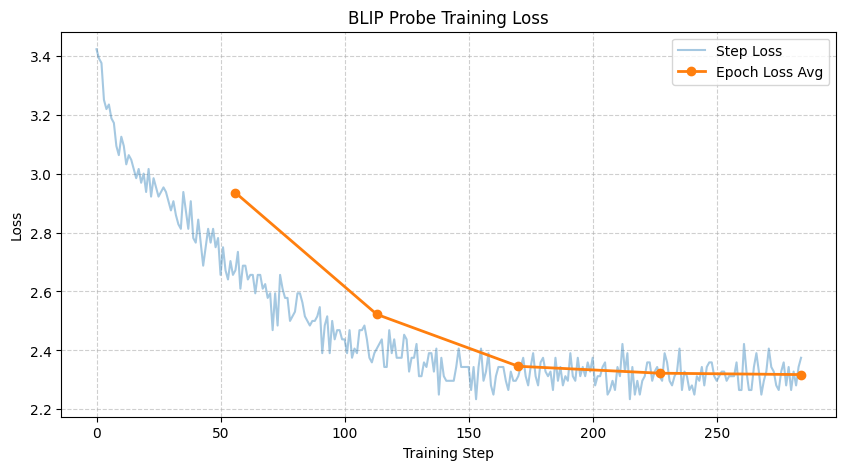

In [16]:
plot_history(probe_history, title="BLIP Probe Training Loss")

In [17]:
probe_metrics, probe_preds, probe_refs = evaluate_captioning(
    probe_model,
    test_data,
    processor,
    device,
    batch_size=16,
    max_new_tokens=50,
    num_beams=1,
    max_eval_samples=None
)

Evaluating BLIP captions:   0%|          | 0/63 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:
log_result("Linear Probe", probe_metrics)


--- Linear Probe ---
BLEU-4: 0.2651
ROUGE-L: 0.3151
METEOR: 0.25
BERTScore: 0.9079


In [18]:
from huggingface_hub import notebook_login
notebook_login()

def upload_blip_to_hf(model, processor, repo_name):
    try:
        model.push_to_hub(repo_name)
        processor.push_to_hub(repo_name)
        print(f"Uploaded model and processor to Hugging Face Hub: {repo_name}")
    except Exception as e:
        print(f"Upload failed: {e}")

In [20]:
upload_blip_to_hf(probe_model, processor, "bdanko/blip-flickr30k-probe")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...z_m7njw/model.safetensors:  16%|#6        | 81.5MB /  495MB            

README.md: 0.00B [00:00, ?B/s]

Uploaded model and processor to Hugging Face Hub: bdanko/blip-flickr30k-probe


# Partial Fine Tune

In [ ]:
def setup_blip_partial_finetune():
    model = BlipForConditionalGeneration.from_pretrained(
        model_id,
        torch_dtype=dtype
    )

    for param in model.parameters():
        param.requires_grad = False

    try:
        for param in model.vision_model.encoder.layers[-1].parameters():
            param.requires_grad = True
        print("Unfroze final vision encoder block.")
    except Exception as e:
        print(f"Could not unfreeze final vision block: {e}")

    try:
        for param in model.text_decoder.bert.encoder.layer[-1].parameters():
            param.requires_grad = True
        print("Unfroze final text decoder block.")
    except Exception as e:
        print(f"Could not unfreeze final decoder block: {e}")

    for name, param in model.named_parameters():
        if "cls" in name or "lm_head" in name:
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())

    print(f"Trainable parameters: {trainable:,} / {total:,} ({100 * trainable / total:.4f}%)")

    return model

In [13]:
train_loader = make_loader(train_data, processor, batch_size=128, shuffle=True)
epochs = 5
lr = 5e-5

In [14]:
partial_model = setup_blip_partial_finetune()

partial_model, partial_history = train_blip_model(
    partial_model,
    train_loader,
    epochs=epochs,
    lr=lr,
    gradient_accumulation_steps=1
)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Unfroze final vision encoder block.
Unfroze final text decoder block.
Trainable parameters: 40,635,256 / 247,444,600 (16.4220%)


Epoch 1/5:   0%|          | 0/227 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/227 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aaa1a339f80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aaa1a339f80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 4/5:   0%|          | 0/227 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aaa1a339f80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7aaa1a339f80>^
^Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self._parent_pid == os.getpid(), 'can only test a child process'self._shutdown_workers()

   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive(): 
              ^^^^^^^^^^^^^^^^^^^^^^^^^

Epoch 5/5:   0%|          | 0/227 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aaa1a339f80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7aaa1a339f80>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^if w.is_alive():^
^ ^ ^ ^ ^ ^ ^ ^^^

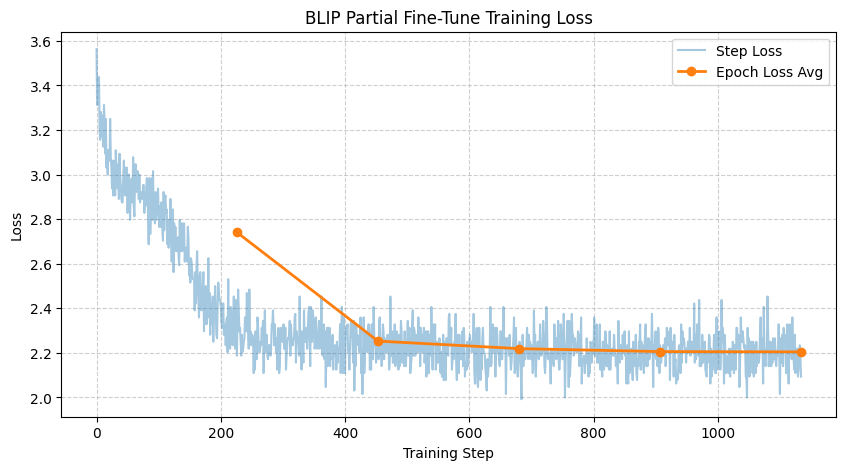

In [15]:
plot_history(partial_history, title="BLIP Partial Fine-Tune Training Loss")

In [16]:
partial_metrics, partial_preds, partial_refs = evaluate_captioning(
    partial_model,
    test_data,
    processor,
    device,
    batch_size=16,
    max_new_tokens=50,
    num_beams=1,
    max_eval_samples=None
)

log_result("Partial Fine-tune", partial_metrics)

Evaluating BLIP captions:   0%|          | 0/63 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Partial Fine-tune ---
BLEU-4: 0.2693
ROUGE-L: 0.3232
METEOR: 0.2647
BERTScore: 0.9093


In [20]:
upload_blip_to_hf(partial_model, processor, "bdanko/blip-flickr30k-partial-finetune")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...e4di35f/model.safetensors:  24%|##3       |  117MB /  495MB            

README.md: 0.00B [00:00, ?B/s]

Uploaded model and processor to Hugging Face Hub: bdanko/blip-flickr30k-partial-finetune


# LoRA

In [10]:
train_loader = make_loader(train_data, processor, batch_size=64, shuffle=True)
epochs = 5
lr = 5e-5

In [11]:
from peft import LoraConfig, get_peft_model, TaskType

In [12]:
def setup_blip_lora():
    model = BlipForConditionalGeneration.from_pretrained(
        model_id,
        torch_dtype=dtype
    )

    config = LoraConfig(
        r=16,
        lora_alpha=16,
        # 'qkv' for the Vision Encoder
        # 'query', 'key', 'value' for the Text Decoder
        target_modules=[
            "qkv",
            "query",
            "key",
            "value"
        ],
        lora_dropout=0.1,
        bias="none"
    )

    model = get_peft_model(model, config)
    model.print_trainable_parameters()

    return model

In [13]:
lora_model = setup_blip_lora()

lora_model, lora_history = train_blip_model(
    lora_model,
    train_loader,
    epochs=epochs,
    lr=lr,
    gradient_accumulation_steps=1
)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

trainable params: 2,359,296 || all params: 249,803,896 || trainable%: 0.9445


Epoch 1/5:   0%|          | 0/454 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/454 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e7f0f5ae520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e7f0f5ae520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 4/5:   0%|          | 0/454 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e7f0f5ae520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e7f0f5ae520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 5/5:   0%|          | 0/454 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e7f0f5ae520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e7f0f5ae520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

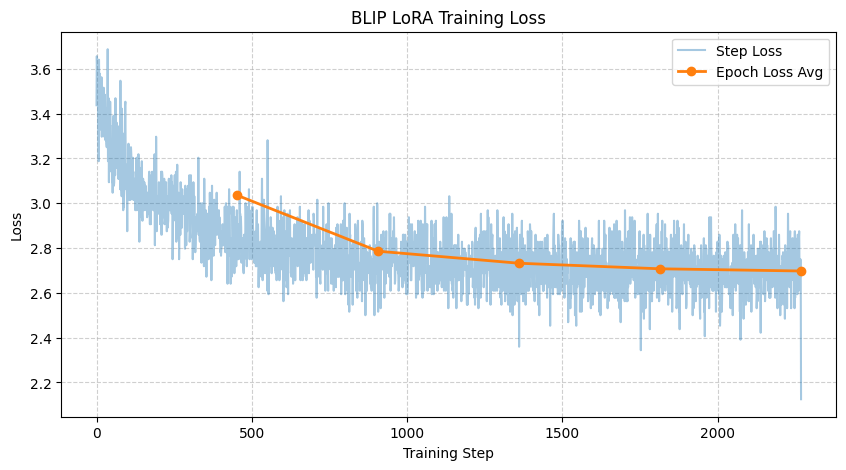

In [14]:
plot_history(lora_history, title="BLIP LoRA Training Loss")

In [15]:

lora_metrics, lora_preds, lora_refs = evaluate_captioning(
    lora_model,
    test_data,
    processor,
    device,
    batch_size=16,
    max_new_tokens=50,
    num_beams=1,
    max_eval_samples=None
)

log_result("LoRA", lora_metrics)

Evaluating BLIP captions:   0%|          | 0/63 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- LoRA ---
BLEU-4: 0.1576
ROUGE-L: 0.3096
METEOR: 0.2692
BERTScore: 0.8978


In [17]:
from huggingface_hub import notebook_login
notebook_login()

def upload_blip_to_hf(model, processor, repo_name):
    try:
        model.push_to_hub(repo_name)
        processor.push_to_hub(repo_name)
        print(f"Uploaded model and processor to Hugging Face Hub: {repo_name}")
    except Exception as e:
        print(f"Upload failed: {e}")

upload_blip_to_hf(lora_model, processor, "bdanko/blip-flickr30k-lora-finetune")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   6%|5         |  557kB / 9.46MB            

README.md: 0.00B [00:00, ?B/s]

Uploaded model and processor to Hugging Face Hub: bdanko/blip-flickr30k-lora-finetune


# Full Fine Tune

In [10]:
train_loader = make_loader(train_data, processor, batch_size=32, shuffle=True)
epochs = 2
lr = 5e-6

In [11]:
full_model = BlipForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=dtype
)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

In [12]:
for param in full_model.parameters():
    param.requires_grad = True

full_model, full_history = train_blip_model(
    full_model,
    train_loader,
    epochs=epochs,
    lr=lr,
    gradient_accumulation_steps=1
)

Epoch 1/2:   0%|          | 0/907 [00:00<?, ?it/s]

Epoch 2/2:   0%|          | 0/907 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bdc75bc6520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


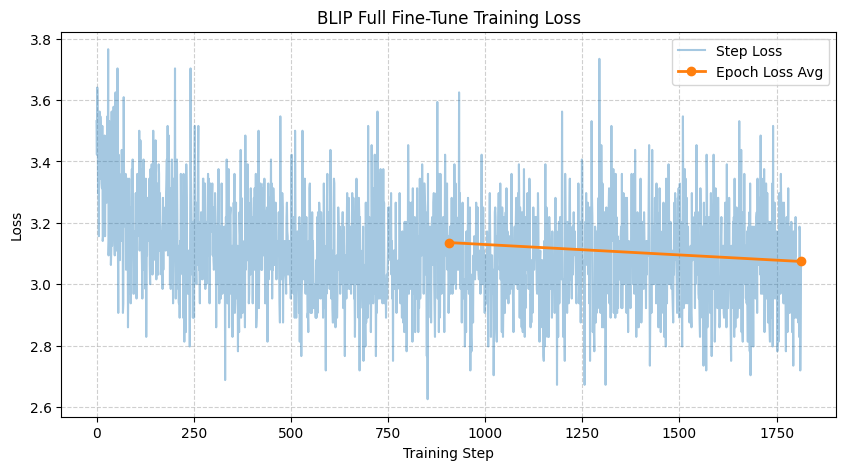

In [13]:
plot_history(full_history, title="BLIP Full Fine-Tune Training Loss")

In [14]:
full_metrics, full_preds, full_refs = evaluate_captioning(
    full_model,
    test_data,
    processor,
    device,
    batch_size=16,
    max_new_tokens=50,
    num_beams=1,
    max_eval_samples=None
)

log_result("Full Fine-tune", full_metrics)

Evaluating BLIP captions:   0%|          | 0/63 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Full Fine-tune ---
BLEU-4: 0.2371
ROUGE-L: 0.3122
METEOR: 0.217
BERTScore: 0.9035


In [16]:
from huggingface_hub import notebook_login
notebook_login()

def upload_blip_to_hf(model, processor, repo_name):
    try:
        model.push_to_hub(repo_name)
        processor.push_to_hub(repo_name)
        print(f"Uploaded model and processor to Hugging Face Hub: {repo_name}")
    except Exception as e:
        print(f"Upload failed: {e}")

upload_blip_to_hf(full_model, processor, "bdanko/blip-flickr30k-full-finetune")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...etqmrvn/model.safetensors:   1%|          | 4.73MB /  495MB            

README.md: 0.00B [00:00, ?B/s]

Uploaded model and processor to Hugging Face Hub: bdanko/blip-flickr30k-full-finetune
